# Midterm Project: CNN Classification of Martian Surface Features

## Objective
The aim of this project is to design, train, and evaluate a convolutional neural network (CNN) to classify Mars HiRISE images into 8 geological surface feature classes.

## 1. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import random
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle as sk_shuffle

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import load_img, img_to_array, plot_model

In [6]:
# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Paths
ZIP_PATH = Path("/content/hirise-map-proj-v3.zip")
EXTRACT_DIR = Path("/content/hirise_extracted")
OUTPUT_DIR = Path("/content/outputs")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------- Training settings --------
IMG_SIZE = (64, 64)    # start small for speed; can increase later to 96x96 or 128x128
BATCH_SIZE = 64
EPOCHS = 20
TEST_SIZE = 0.15
VAL_SIZE = 0.15        # final split: train / val / test = 70 / 15 / 15 approx
MAX_SAMPLES = None     # set e.g. 20000 for quick experiments; keep None for full dataset

print("ZIP_PATH:", ZIP_PATH)
print("EXTRACT_DIR:", EXTRACT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

ZIP_PATH: /content/hirise-map-proj-v3.zip
EXTRACT_DIR: /content/hirise_extracted
OUTPUT_DIR: /content/outputs


## 2. Unzipping and inspecting the dataset

In [9]:
# =========================
# 2. Unzip and inspect dataset
# =========================
def unzip_dataset(zip_path: Path, extract_dir: Path) -> Path:
    """
    Unzip the dataset if not already extracted.
    Returns the extraction directory.
    """
    if not zip_path.exists():
        raise FileNotFoundError(
            f"ZIP file not found at {zip_path}. Please upload 'hirise-map-proj-v3.zip' and update ZIP_PATH."
        )

    extract_dir.mkdir(parents=True, exist_ok=True)

    # If already extracted and contains many files, skip re-extraction
    existing_files = list(extract_dir.rglob("*"))
    if len(existing_files) > 100:
        print(f"Dataset appears already extracted ({len(existing_files)} items). Skipping unzip.")
        return extract_dir

    print("Extracting ZIP... this may take a while.")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Extraction complete.")
    return extract_dir


def print_tree_summary(root: Path, max_depth: int = 2, max_entries_per_dir: int = 10):
    """
    Print a lightweight summary of the folder structure.
    """
    root = Path(root)
    print(f"\nFolder summary for: {root}\n")
    for path, dirs, files in os.walk(root):
        rel = Path(path).relative_to(root)
        depth = len(rel.parts)
        if depth > max_depth:
            continue
        indent = "  " * depth
        print(f"{indent}- {Path(path).name}/  ({len(files)} files)")
        for f in files[:max_entries_per_dir]:
            print(f"{indent}    • {f}")
        if len(files) > max_entries_per_dir:
            print(f"{indent}    ... ({len(files) - max_entries_per_dir} more files)")


def count_image_files(root: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    image_paths = [p for p in root.rglob("*") if p.suffix.lower() in exts]
    return image_paths


data_root = unzip_dataset(ZIP_PATH, EXTRACT_DIR)
print_tree_summary(data_root, max_depth=2, max_entries_per_dir=8)

image_paths_all = count_image_files(data_root)
print(f"\nTotal image files found: {len(image_paths_all)}")
if len(image_paths_all) < 70000:
    print("WARNING: Fewer than expected images found. Check the ZIP/unzipping and file paths.")


Dataset appears already extracted (73037 items). Skipping unzip.

Folder summary for: /content/hirise_extracted

- hirise_extracted/  (3 files)
    • README.txt
    • landmarks_map-proj-v3_classmap.csv
    • labels-map-proj-v3.txt
  - __MACOSX/  (1 files)
      • ._README.txt
  - map-proj-v3/  (73031 files)
      • ESP_025758_1475_RED-0303.jpg
      • ESP_016773_2010_RED-0033-fv.jpg
      • ESP_026511_2330_RED-0211-brt.jpg
      • ESP_013788_1910_RED-0169-fv.jpg
      • PSP_005072_1375_RED-0431-fv.jpg
      • ESP_020606_1445_RED-0679-r270.jpg
      • ESP_025151_1570_RED-0387-brt.jpg
      • PSP_010587_1620_RED-0078-fh.jpg
      ... (73023 more files)

Total image files found: 73031


## 3. Reading labels into a DataFrame

In [10]:
# =========================
# 3. Find and parse labels file
# =========================
def find_candidate_label_files(root: Path):
    """
    Find candidate text/csv label files.
    """
    candidates = []
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in {".txt", ".csv"}:
            name = p.name.lower()
            # Heuristics: label/list/map/proj usually appear in dataset metadata file names
            if any(k in name for k in ["label", "labels", "class", "map", "proj"]):
                candidates.append(p)
    return candidates


def parse_labels_file(label_file: Path) -> pd.DataFrame:
    """
    Parse a labels file where each line looks like:
        <filename> <class name possibly with spaces>
    Returns DataFrame with columns ['filename', 'class'].
    """
    rows = []
    with open(label_file, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Skip obvious comments/headers
            if line.startswith("#"):
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            filename = parts[0]
            cls = " ".join(parts[1:]).strip()

            # Basic header filtering (if any)
            low = (filename + " " + cls).lower()
            if "filename" in low and "class" in low:
                continue

            rows.append((filename, cls))

    df = pd.DataFrame(rows, columns=["filename", "class"])
    if df.empty:
        raise ValueError(f"Could not parse any labels from: {label_file}")

    # Clean whitespace
    df["filename"] = df["filename"].astype(str).str.strip()
    df["class"] = df["class"].astype(str).str.strip()
    return df


candidates = find_candidate_label_files(data_root)
print("Candidate label files:")
for i, c in enumerate(candidates):
    print(f"{i}: {c}")

if not candidates:
    raise FileNotFoundError("No candidate labels file found. Inspect extracted files manually.")

# Try candidates and keep the one with most parsed rows
best_df = None
best_file = None
for c in candidates:
    try:
        tmp_df = parse_labels_file(c)
        if best_df is None or len(tmp_df) > len(best_df):
            best_df = tmp_df
            best_file = c
    except Exception as e:
        print(f"Skipping {c.name}: {e}")

if best_df is None:
    raise RuntimeError("No valid labels file could be parsed.")

df_labels = best_df.copy()
print(f"\nSelected labels file: {best_file}")
print(f"Rows parsed: {len(df_labels)}")
print(df_labels.head())
print("\nClass counts (raw labels):")
print(df_labels["class"].value_counts())

Candidate label files:
0: /content/hirise_extracted/landmarks_map-proj-v3_classmap.csv
1: /content/hirise_extracted/labels-map-proj-v3.txt

Selected labels file: /content/hirise_extracted/labels-map-proj-v3.txt
Rows parsed: 73031
                            filename class
0       ESP_011623_2100_RED-0069.jpg     0
1   ESP_011623_2100_RED-0069-r90.jpg     0
2  ESP_011623_2100_RED-0069-r180.jpg     0
3  ESP_011623_2100_RED-0069-r270.jpg     0
4    ESP_011623_2100_RED-0069-fh.jpg     0

Class counts (raw labels):
class
0    61054
1     4900
3     2331
4     1750
6     1148
2     1141
7      476
5      231
Name: count, dtype: int64


## 4. Building full image paths and validating records

In [11]:
# =========================
# 4. Build full paths and validate rows
# =========================
def build_image_index(root: Path):
    """
    Build a basename -> list of full paths mapping for all image files.
    Useful if the labels file stores only filenames.
    """
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    index = {}
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            index.setdefault(p.name, []).append(p)
    return index


def resolve_filepath(filename: str, root: Path, img_index: dict) -> str | None:
    """
    Resolve a filename to an existing image path.
    Handles:
    - direct path relative to root
    - basename lookup
    """
    # Case 1: labels file stores relative path
    p1 = (root / filename)
    if p1.exists():
        return str(p1)

    # Case 2: labels file stores basename only
    basename = Path(filename).name
    matches = img_index.get(basename, [])
    if len(matches) == 1:
        return str(matches[0])
    elif len(matches) > 1:
        # If duplicates exist, use the first and record ambiguity if needed
        return str(matches[0])
    return None


print("Building image index (this may take some time on full dataset)...")
img_index = build_image_index(data_root)
print(f"Indexed {sum(len(v) for v in img_index.values())} image files")

df = df_labels.copy()
df["filepath"] = df["filename"].apply(lambda x: resolve_filepath(x, data_root, img_index))
df["exists"] = df["filepath"].notna()

missing_count = (~df["exists"]).sum()
print(f"Missing image rows: {missing_count} / {len(df)}")

df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

# Optional subset for speed (keep stratified-ish later)
if MAX_SAMPLES is not None and MAX_SAMPLES < len(df):
    df = (
        df.groupby("class", group_keys=False)
          .apply(lambda g: g.sample(max(1, int(MAX_SAMPLES * len(g) / len(df))), random_state=SEED))
          .reset_index(drop=True)
    )
    print(f"Using subset: {len(df)} rows")

print("\nCleaned dataframe:")
print(df.head())
print("\nFinal class distribution:")
print(df["class"].value_counts())
print(f"\nTotal valid rows: {len(df)}")

Building image index (this may take some time on full dataset)...
Indexed 73031 image files
Missing image rows: 0 / 73031

Cleaned dataframe:
                            filename class  \
0       ESP_011623_2100_RED-0069.jpg     0   
1   ESP_011623_2100_RED-0069-r90.jpg     0   
2  ESP_011623_2100_RED-0069-r180.jpg     0   
3  ESP_011623_2100_RED-0069-r270.jpg     0   
4    ESP_011623_2100_RED-0069-fh.jpg     0   

                                            filepath  
0  /content/hirise_extracted/map-proj-v3/ESP_0116...  
1  /content/hirise_extracted/map-proj-v3/ESP_0116...  
2  /content/hirise_extracted/map-proj-v3/ESP_0116...  
3  /content/hirise_extracted/map-proj-v3/ESP_0116...  
4  /content/hirise_extracted/map-proj-v3/ESP_0116...  

Final class distribution:
class
0    61054
1     4900
3     2331
4     1750
6     1148
2     1141
7      476
5      231
Name: count, dtype: int64

Total valid rows: 73031


## 5. Initial data exploration

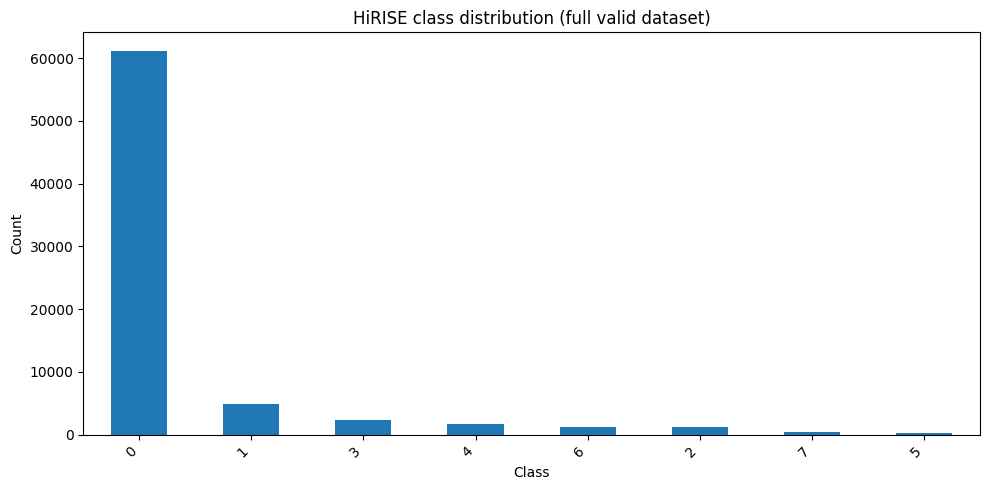

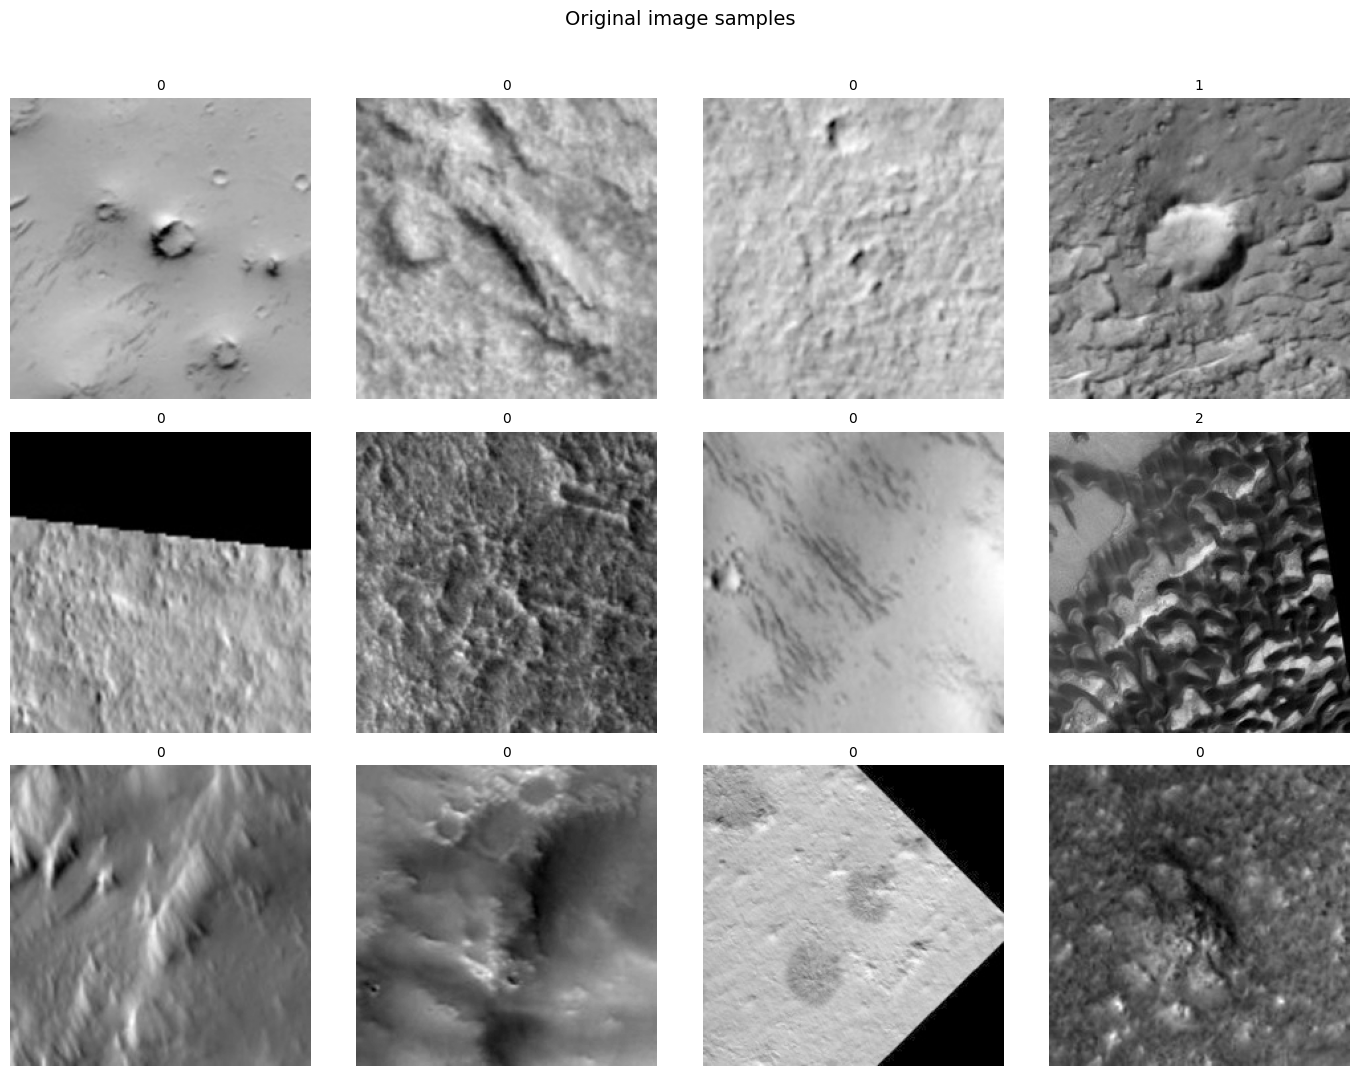

In [17]:
# =========================
# 5. Class distribution and original image samples
# =========================
def plot_class_distribution(df: pd.DataFrame, title: str = "Class distribution"):
    counts = df["class"].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def show_original_samples(df: pd.DataFrame, n: int = 12, seed: int = 42):
    sample_df = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)
    ncols = 4
    nrows = int(np.ceil(len(sample_df) / ncols))
    plt.figure(figsize=(14, 3.5 * nrows))

    for i, row in sample_df.iterrows():
        img = Image.open(row["filepath"])
        ax = plt.subplot(nrows, ncols, i + 1)
        # Convert to display-friendly array
        arr = np.array(img)
        if arr.ndim == 2:
            ax.imshow(arr, cmap="gray")
        else:
            ax.imshow(arr)
        ax.set_title(row["class"], fontsize=10)
        ax.axis("off")

    plt.suptitle("Original image samples", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_class_distribution(df, title="HiRISE class distribution (full valid dataset)")
show_original_samples(df, n=12, seed=SEED)

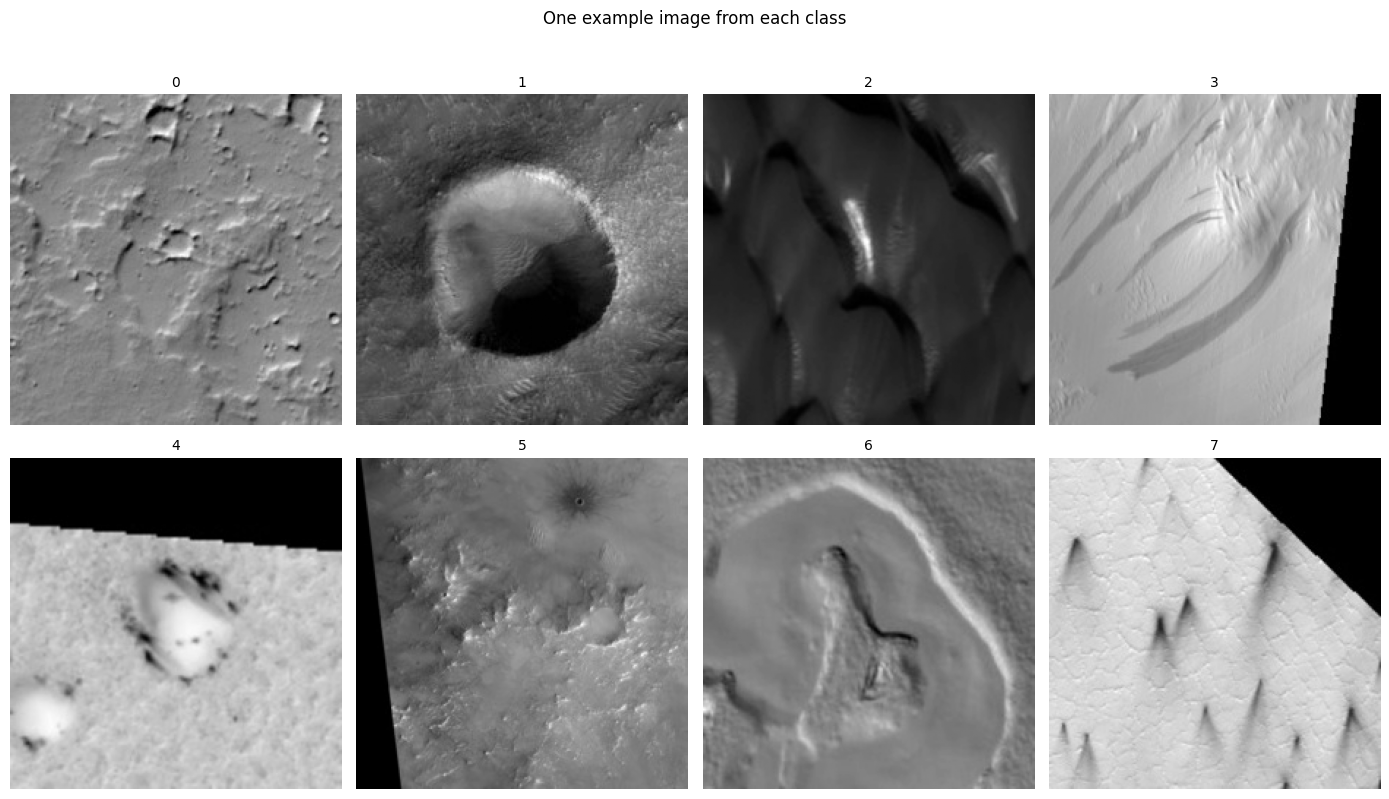

In [31]:
# Extra plot: one sample per class
one_per_class = df.groupby("class", group_keys=False).apply(lambda g: g.sample(1, random_state=SEED)).reset_index(drop=True)

plt.figure(figsize=(14, 8))
for i, row in one_per_class.iterrows():
    img = Image.open(row["filepath"])
    arr = np.array(img)
    ax = plt.subplot(2, 4, i + 1)
    if arr.ndim == 2:
        ax.imshow(arr, cmap="gray")
    else:
        ax.imshow(arr)
    ax.set_title(row["class"], fontsize=10)
    ax.axis("off")

plt.suptitle("One example image from each class", y=1.02)
plt.tight_layout()
plt.show()

## 6. Shuffling and train/validation/test split

In [18]:
# =========================
# 6. Shuffle and stratified split
# =========================
df = sk_shuffle(df, random_state=SEED).reset_index(drop=True)

# First split off test set
train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["class"]
)

# Split remaining into train + val
val_fraction_of_trainval = VAL_SIZE / (1.0 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_fraction_of_trainval,
    random_state=SEED,
    stratify=train_val_df["class"]
)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

print("\nTrain class distribution:")
print(train_df["class"].value_counts(normalize=True).sort_index())
print("\nVal class distribution:")
print(val_df["class"].value_counts(normalize=True).sort_index())
print("\nTest class distribution:")
print(test_df["class"].value_counts(normalize=True).sort_index())

Train size: 51121
Val size:   10955
Test size:  10955

Train class distribution:
class
0    0.836017
1    0.067096
2    0.015630
3    0.031905
4    0.023963
5    0.003149
6    0.015727
7    0.006514
Name: proportion, dtype: float64

Val class distribution:
class
0    0.835965
1    0.067093
2    0.015609
3    0.031949
4    0.023916
5    0.003195
6    0.015701
7    0.006572
Name: proportion, dtype: float64

Test class distribution:
class
0    0.835965
1    0.067093
2    0.015609
3    0.031949
4    0.024007
5    0.003195
6    0.015701
7    0.006481
Name: proportion, dtype: float64


## 7. Image preprocessing and data generators

In [19]:
# =========================
# 7. Preprocessing and Keras generators
# =========================
def infer_color_mode(sample_path: str) -> str:
    """
    Infer whether images should be loaded as grayscale or rgb.
    """
    img = Image.open(sample_path)
    arr = np.array(img)
    if arr.ndim == 2:
        return "grayscale"
    if arr.ndim == 3 and arr.shape[2] == 1:
        return "grayscale"
    return "rgb"


sample_path = train_df.iloc[0]["filepath"]
COLOR_MODE = infer_color_mode(sample_path)
CHANNELS = 1 if COLOR_MODE == "grayscale" else 3
print("Detected color mode:", COLOR_MODE)

# Basic preprocessing (course hint strongly suggests rescaling to [0,1])
train_idg = ImageDataGenerator(rescale=1.0 / 255.0)
val_test_idg = ImageDataGenerator(rescale=1.0 / 255.0)

# For flow_from_dataframe, using filepaths directly (directory=None)
train_gen = train_idg.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="class",
    target_size=IMG_SIZE,
    color_mode=COLOR_MODE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validate_filenames=False
)

val_gen = val_test_idg.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="class",
    target_size=IMG_SIZE,
    color_mode=COLOR_MODE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validate_filenames=False
)

test_gen = val_test_idg.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="class",
    target_size=IMG_SIZE,
    color_mode=COLOR_MODE,
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False,  # IMPORTANT for evaluation/prediction alignment
    validate_filenames=False
)

print("\nClass indices used by generator:")
print(train_gen.class_indices)
print(f"\nSamples -> train: {train_gen.samples}, val: {val_gen.samples}, test: {test_gen.samples}")

Detected color mode: grayscale
Found 51121 non-validated image filenames belonging to 8 classes.
Found 10955 non-validated image filenames belonging to 8 classes.
Found 10955 non-validated image filenames belonging to 8 classes.

Class indices used by generator:
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7}

Samples -> train: 51121, val: 10955, test: 10955


## 8. Visualising preprocessed images


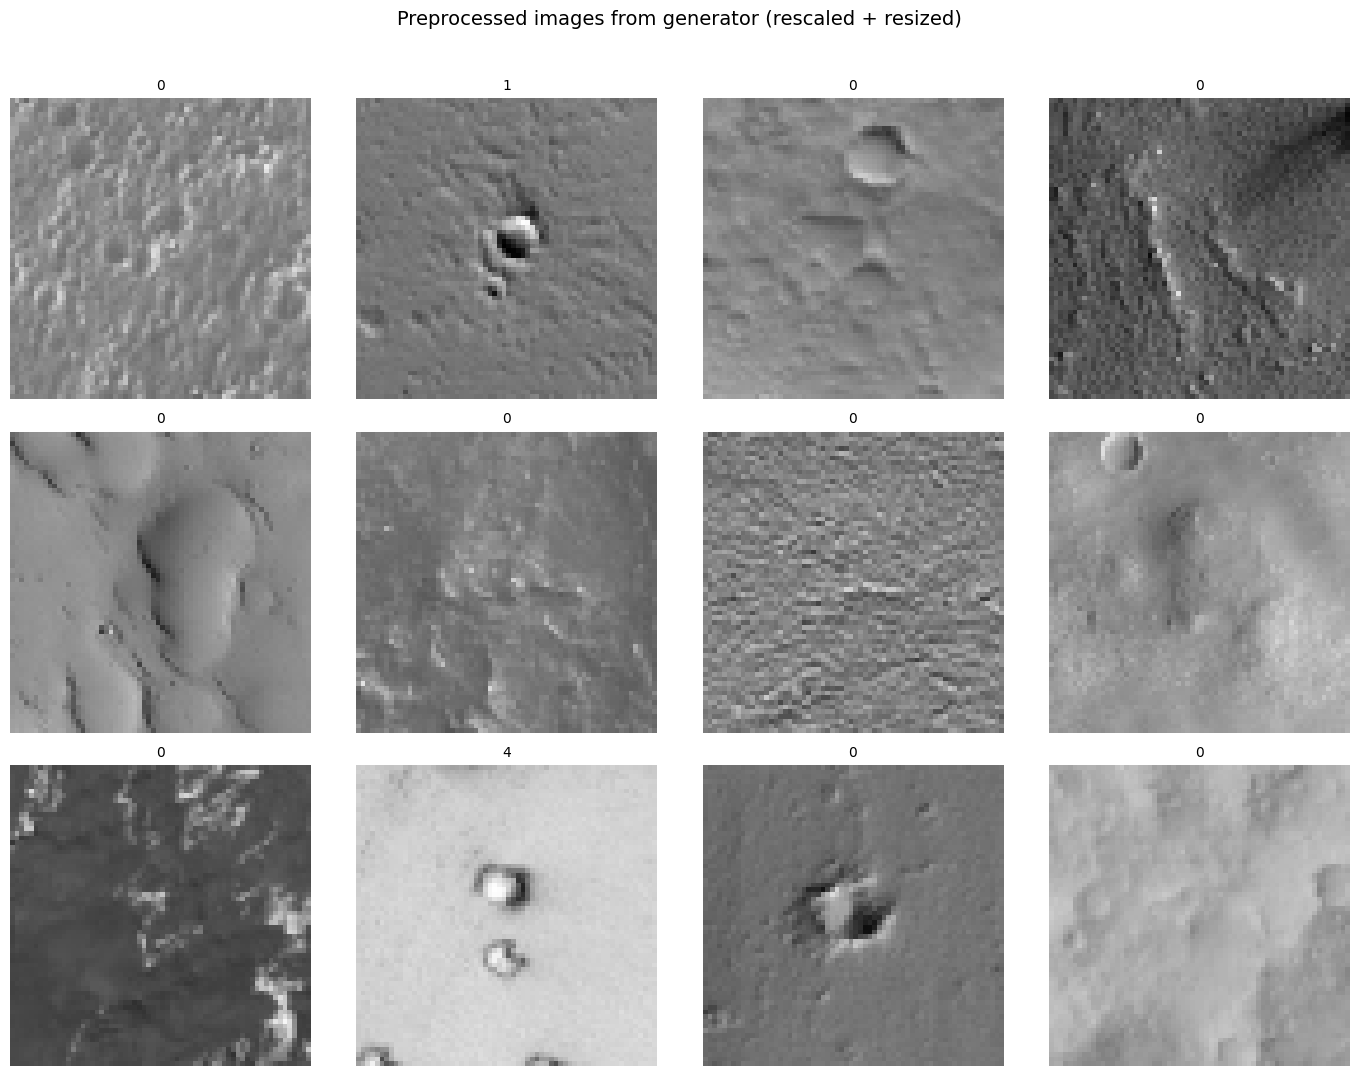

In [20]:
# =========================
# 8. Visualise preprocessed images
# =========================
def show_generator_batch(generator, class_indices: dict, n: int = 12):
    images, labels = generator[0]  # first batch
    inv_class = {v: k for k, v in class_indices.items()}

    n = min(n, len(images))
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(14, 3.5 * nrows))

    for i in range(n):
        ax = plt.subplot(nrows, ncols, i + 1)
        img = images[i]
        if img.shape[-1] == 1:
            ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
        else:
            ax.imshow(img)
        cls_idx = int(np.argmax(labels[i]))
        ax.set_title(inv_class[cls_idx], fontsize=10)
        ax.axis("off")

    plt.suptitle("Preprocessed images from generator (rescaled + resized)", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


show_generator_batch(train_gen, train_gen.class_indices, n=12)

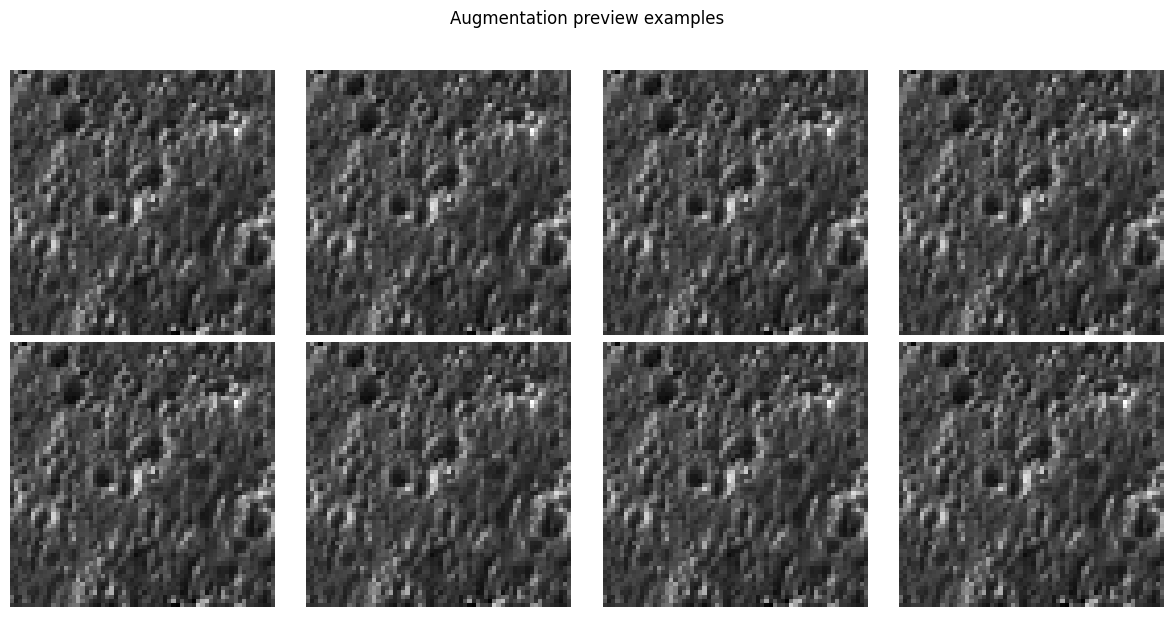

In [34]:
# Extra plot: augmentation preview (only if train_idg uses augmentation)
sample_row = train_df.sample(1, random_state=SEED).iloc[0]
img = load_img(sample_row["filepath"], color_mode=COLOR_MODE, target_size=IMG_SIZE)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

aug_iter = train_idg.flow(x, batch_size=1, shuffle=False)

plt.figure(figsize=(12, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    aug_img = next(aug_iter)[0]
    if aug_img.shape[-1] == 1:
        ax.imshow(aug_img.squeeze(), cmap="gray")
    else:
        ax.imshow(aug_img)
    ax.axis("off")
plt.suptitle("Augmentation preview examples", y=1.02)
plt.tight_layout()
plt.show()

## 9. CNN

In [22]:
# =========================
# 9. CNN model definition
# =========================
def build_cnn(input_shape, n_classes):
    """
    Baseline CNN for 8-class image classification.
    """
    model = models.Sequential(name="hirise_cnn")

    # Block 1
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Block 4
    model.add(layers.Conv2D(256, (3, 3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Classifier head
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(n_classes, activation="softmax"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


input_shape = (IMG_SIZE[0], IMG_SIZE[1], CHANNELS)
n_classes = len(train_gen.class_indices)

model = build_cnn(input_shape=input_shape, n_classes=n_classes)
model.summary()

Model: "hirise_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,440,648 (5.50 MB)

 Trainable params: 1,439,688 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)

### 10. network diagram

In [23]:
# =========================
# 10. Save network diagram (optional but recommended)
# =========================
diagram_path = OUTPUT_DIR / "cnn_architecture.png"

try:
    plot_model(
        model,
        to_file=str(diagram_path),
        show_shapes=True,
        show_layer_names=True,
        expand_nested=False,
        dpi=120
    )
    print(f"Saved model diagram to: {diagram_path}")
except Exception as e:
    print("plot_model could not generate a diagram in this environment.")
    print("Error:", e)
    print("You can still include model.summary() and make a manual architecture figure in the report.")

Saved model diagram to: /content/outputs/cnn_architecture.png


## 11. Training model

In [24]:
# =========================
# 11. Training
# =========================
checkpoint_path = OUTPUT_DIR / "best_hirise_cnn.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8098 - loss: 0.8929
Epoch 1: val_loss improved from inf to 0.76234, saving model to /content/outputs/best_hirise_cnn.keras
799/799 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.8099 - loss: 0.8926 - val_accuracy: 0.8450 - val_loss: 0.7623 - learning_rate: 0.0010
Epoch 2/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8621 - loss: 0.4811
Epoch 2: val_loss improved from 0.76234 to 0.50056, saving model to /content/outputs/best_hirise_cnn.keras
799/799 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.8621 - loss: 0.4811 - val_accuracy: 0.8738 - val_loss: 0.5006 - learning_rate: 0.0010
Epoch 3/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8801 - loss: 0.3929
Epoch 3: val_loss did not improve from 0.50056
799/799 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.8801 - loss: 0.3929 - val_accuracy: 0.6929 - val_loss: 0.9478 - learning_rate: 0.0010
Epoch 4/20
799/799 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step 

## 12. Training curves (accuracy and loss)

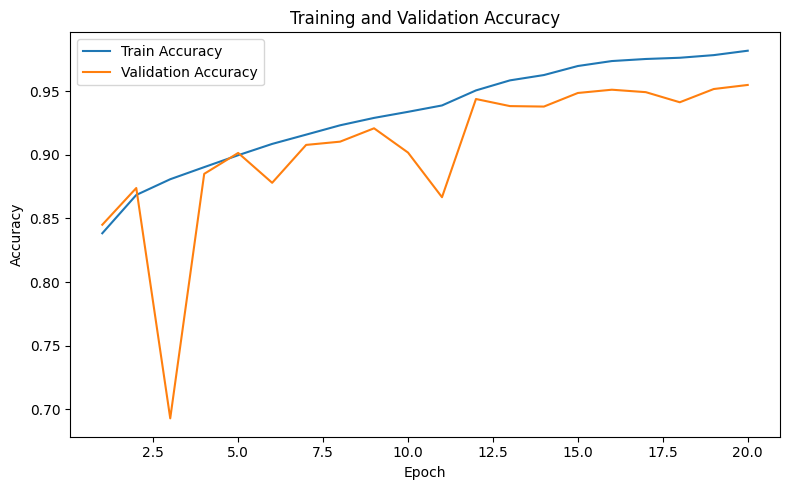

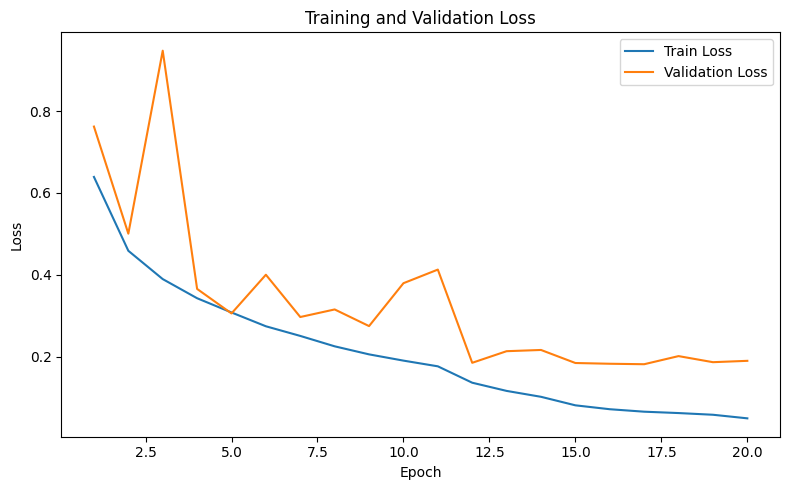

Saved training history to: /content/outputs/training_history.csv


In [25]:
# =========================
# 12. Training curves
# =========================
def plot_training_history(history_obj):
    hist = history_obj.history
    epochs_range = range(1, len(hist["loss"]) + 1)

    # Accuracy plot
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, hist["accuracy"], label="Train Accuracy")
    plt.plot(epochs_range, hist["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Loss plot
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, hist["loss"], label="Train Loss")
    plt.plot(epochs_range, hist["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_training_history(history)

# Save history for report/self-grading use
history_df = pd.DataFrame(history.history)
history_csv_path = OUTPUT_DIR / "training_history.csv"
history_df.to_csv(history_csv_path, index=False)
print(f"Saved training history to: {history_csv_path}")

## 13. Test-set evaluation and per-class performance

In [26]:
# =========================
# 13. Test evaluation and predictions
# =========================
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predict probabilities on test set
test_gen.reset()
y_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

idx_to_class = {v: k for k, v in test_gen.class_indices.items()}
class_names_ordered = [idx_to_class[i] for i in range(len(idx_to_class))]

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=class_names_ordered, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion matrix shape:", cm.shape)

172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 94ms/step - accuracy: 0.9485 - loss: 0.1909
Test Loss: 0.1916
Test Accuracy: 0.9471
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step

Classification report:
              precision    recall  f1-score   support

           0     0.9697    0.9692    0.9695      9158
           1     0.8450    0.8381    0.8415       735
           2     0.8000    0.8655    0.8315       171
           3     0.6612    0.6971    0.6787       350
           4     0.9737    0.9848    0.9792       263
           5     1.0000    0.4000    0.5714        35
           6     0.9286    0.9070    0.9176       172
           7     0.8873    0.8873    0.8873        71

    accuracy                         0.9471     10955
   macro avg     0.8832    0.8186    0.8346     10955
weighted avg     0.9479    0.9471    0.9471     10955


Confusion matrix shape: (8, 8)


## 14. Example test predictions

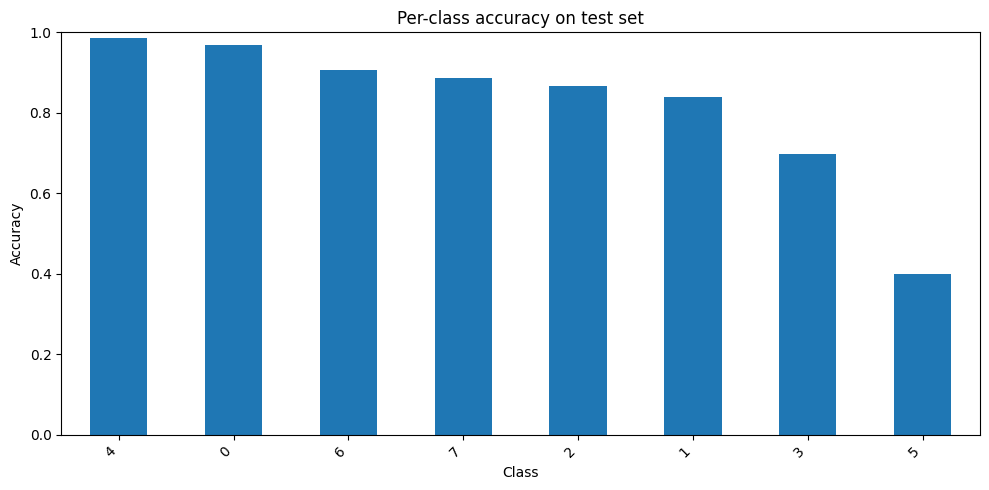

Saved per-class accuracy CSV.


In [27]:
# =========================
# 14. Per-class accuracy plot
# =========================
def compute_per_class_accuracy(y_true, y_pred, class_names):
    per_class = {}
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    for i, cls_name in enumerate(class_names):
        mask = (y_true == i)
        total = mask.sum()
        correct = ((y_pred == i) & mask).sum()
        per_class[cls_name] = correct / total if total > 0 else np.nan
    return per_class


per_class_acc = compute_per_class_accuracy(y_true, y_pred, class_names_ordered)
per_class_acc_series = pd.Series(per_class_acc).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
per_class_acc_series.plot(kind="bar")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.title("Per-class accuracy on test set")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

per_class_acc_df = per_class_acc_series.rename("accuracy").reset_index().rename(columns={"index": "class"})
per_class_acc_df.to_csv(OUTPUT_DIR / "per_class_accuracy.csv", index=False)
print("Saved per-class accuracy CSV.")

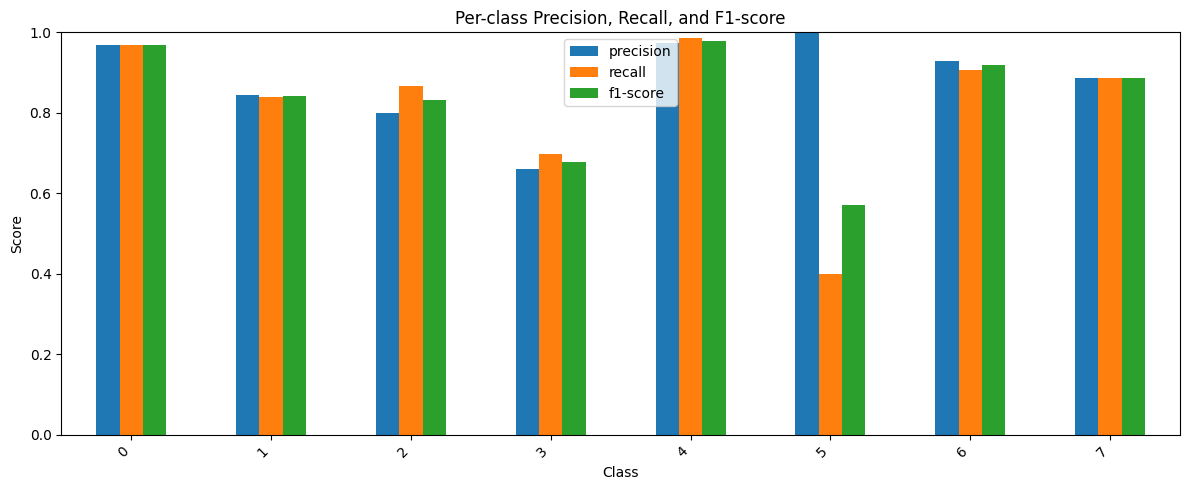

In [37]:
# Extra plot: per-class precision/recall/F1 from classification report
report_dict = classification_report(
    y_true, y_pred,
    target_names=class_names_ordered,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report_dict).T
metrics_df = metrics_df.loc[class_names_ordered, ["precision", "recall", "f1-score"]]

metrics_df.plot(kind="bar", figsize=(12, 5))
plt.title("Per-class Precision, Recall, and F1-score")
plt.ylabel("Score")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 15. Conclusion

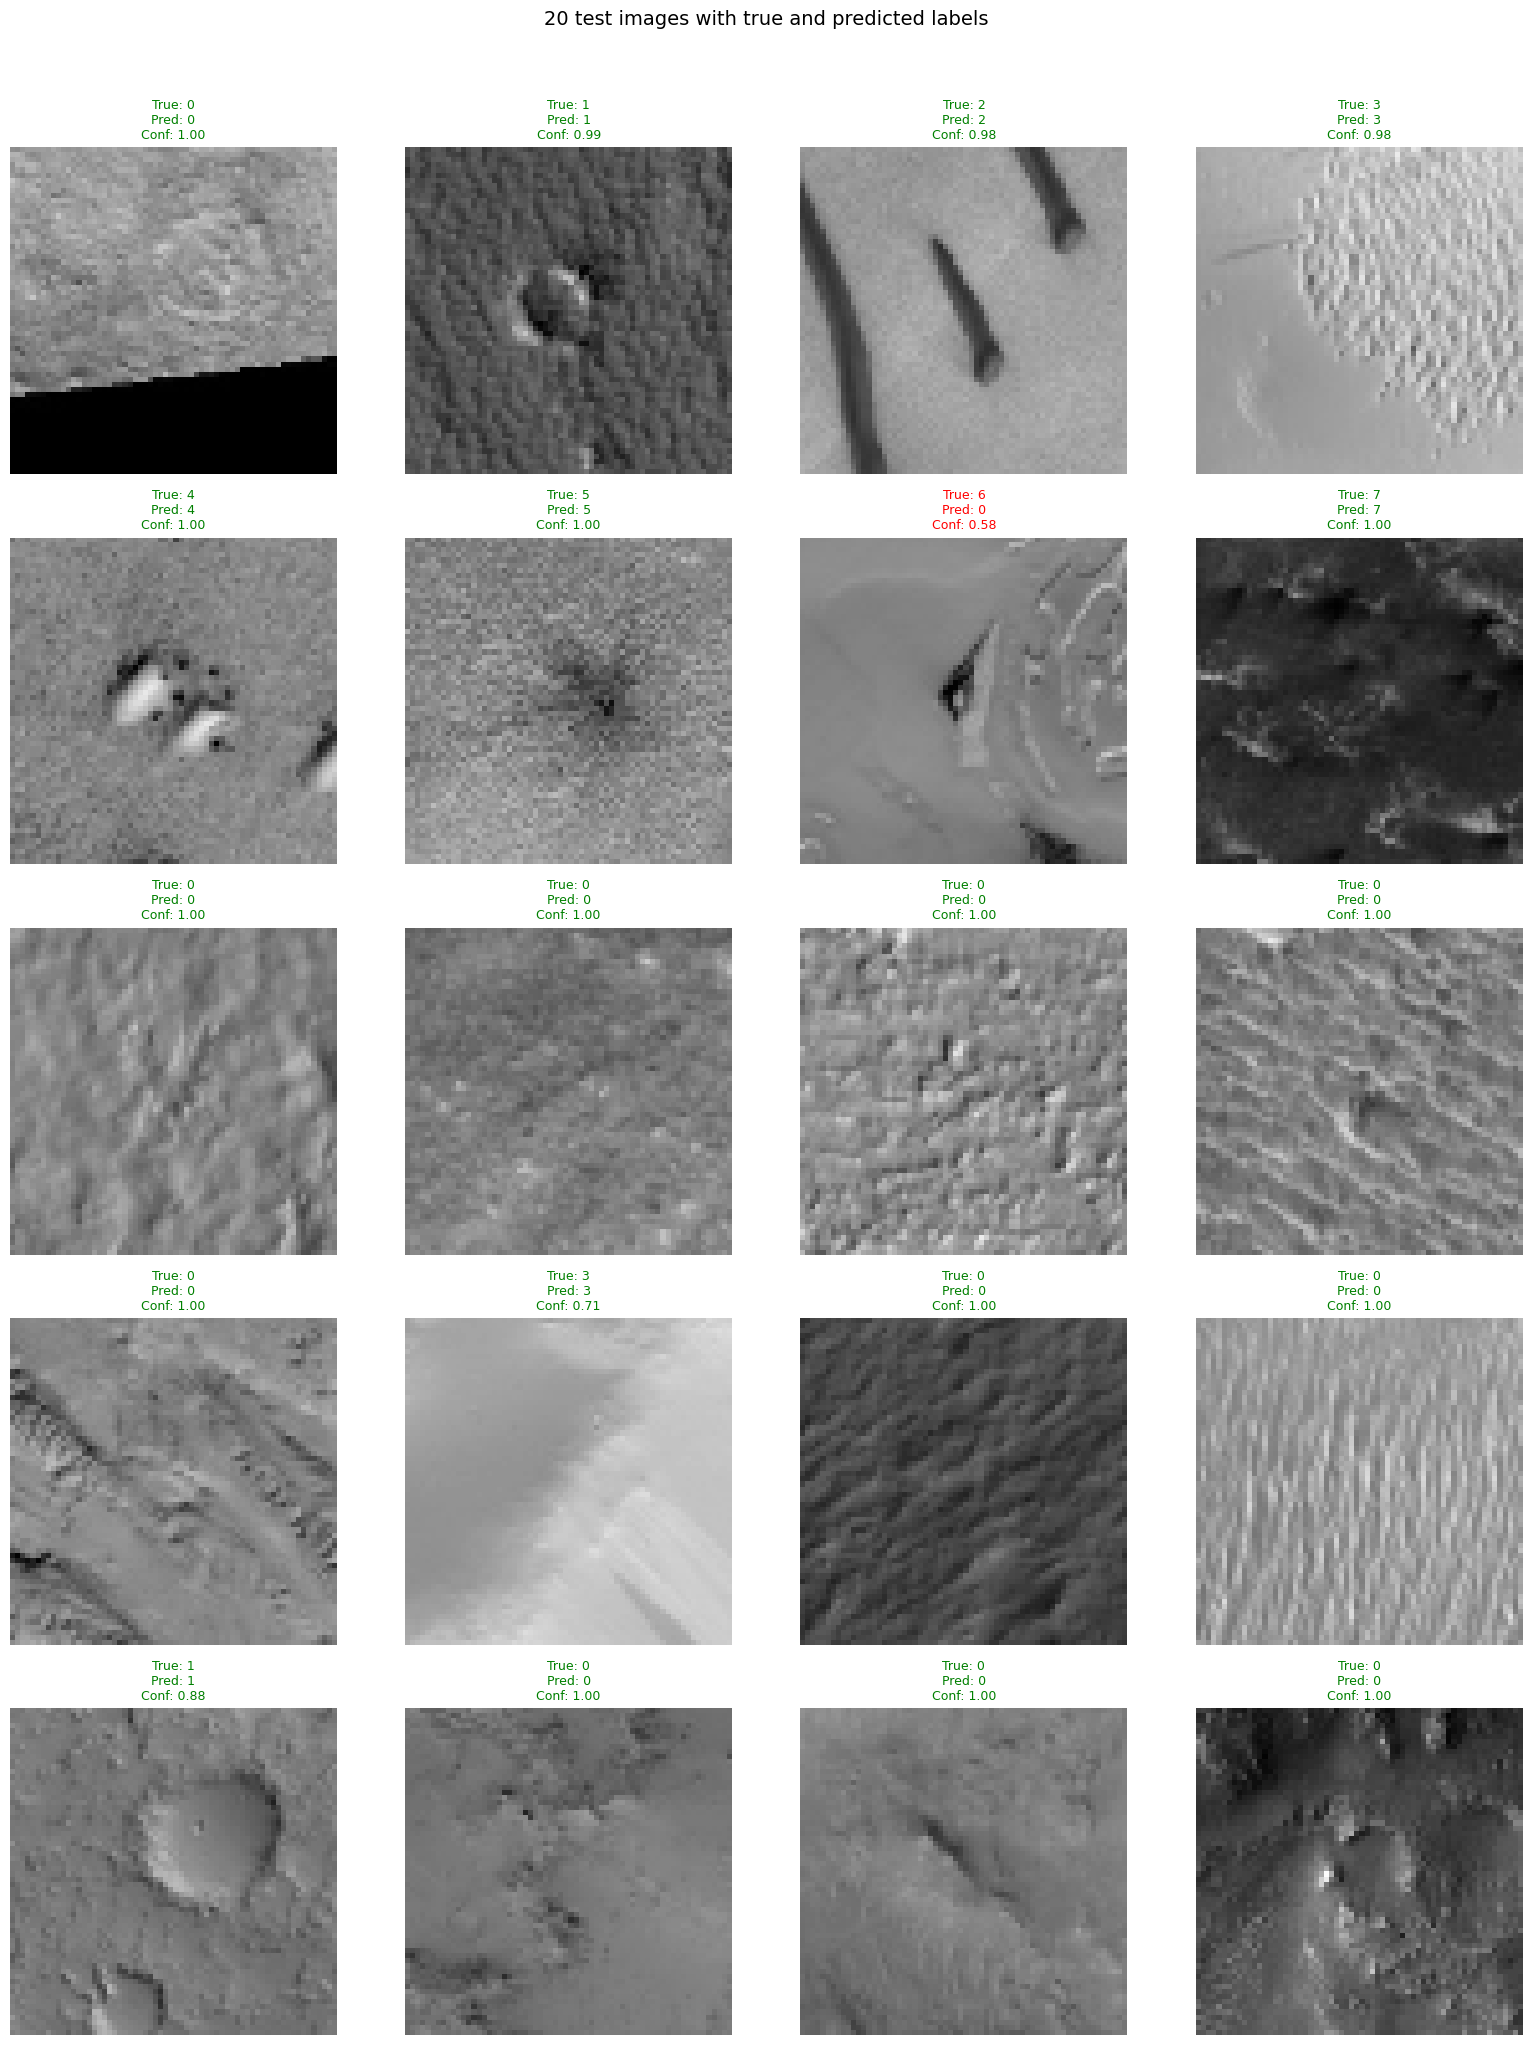

Classes represented in selected examples:
['0', '1', '2', '3', '4', '5', '6', '7']
Number of examples shown: 20


In [28]:
# =========================
# 15. Display 20 test predictions (ensure all classes appear)
# =========================
test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["true_idx"] = y_true
test_df_reset["pred_idx"] = y_pred
test_df_reset["true_label"] = test_df_reset["true_idx"].map(idx_to_class)
test_df_reset["pred_label"] = test_df_reset["pred_idx"].map(idx_to_class)
test_df_reset["pred_conf"] = y_prob.max(axis=1)

# Ensure at least one example from each true class
selected_indices = []

for cls_idx in range(len(class_names_ordered)):
    cls_rows = test_df_reset.index[test_df_reset["true_idx"] == cls_idx].tolist()
    if cls_rows:
        # choose one random row from this class
        selected_indices.append(random.choice(cls_rows))

# Fill remaining slots to total 20 with random non-duplicate rows
remaining_pool = [i for i in test_df_reset.index.tolist() if i not in selected_indices]
random.shuffle(remaining_pool)
target_n = min(20, len(test_df_reset))
selected_indices += remaining_pool[: max(0, target_n - len(selected_indices))]

selected_df = test_df_reset.loc[selected_indices].reset_index(drop=True)

def display_prediction_grid(df_pred: pd.DataFrame, img_size=(64, 64), color_mode="grayscale"):
    n = len(df_pred)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(16, 4 * nrows))

    for i, row in df_pred.iterrows():
        ax = plt.subplot(nrows, ncols, i + 1)
        img = load_img(
            row["filepath"],
            color_mode=color_mode,
            target_size=img_size
        )
        arr = img_to_array(img) / 255.0

        if arr.shape[-1] == 1:
            ax.imshow(arr.squeeze(), cmap="gray", vmin=0, vmax=1)
        else:
            ax.imshow(arr)

        title_color = "green" if row["true_label"] == row["pred_label"] else "red"
        ax.set_title(
            f"True: {row['true_label']}\nPred: {row['pred_label']}\nConf: {row['pred_conf']:.2f}",
            fontsize=9,
            color=title_color
        )
        ax.axis("off")

    plt.suptitle("20 test images with true and predicted labels", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

display_prediction_grid(selected_df, img_size=IMG_SIZE, color_mode=COLOR_MODE)

print("Classes represented in selected examples:")
print(sorted(selected_df['true_label'].unique()))
print(f"Number of examples shown: {len(selected_df)}")

### Confusion matrix heatmap

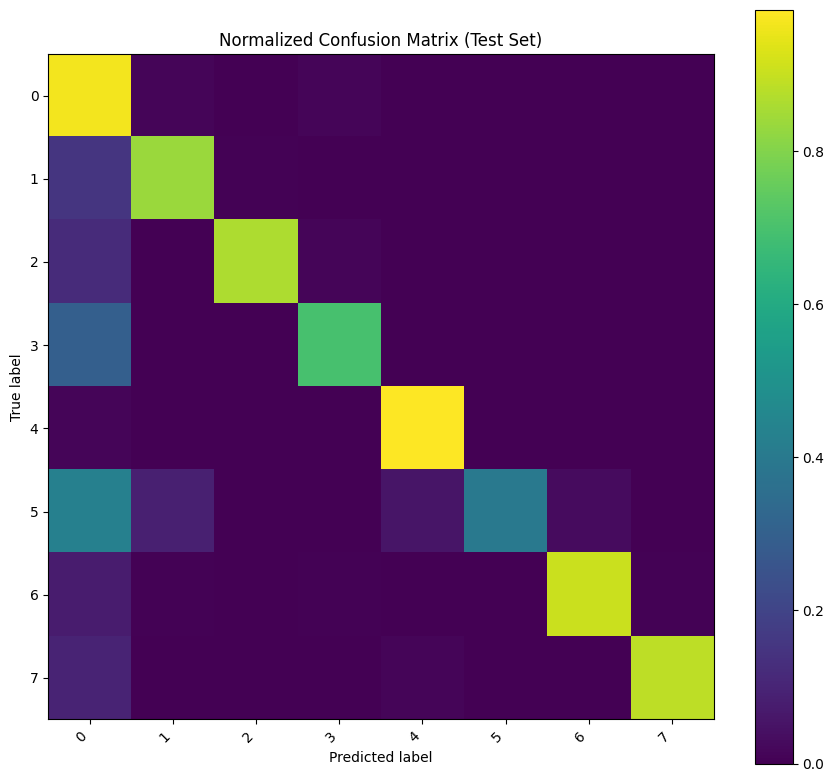

In [36]:
# =========================
# 16. Optional confusion matrix plot
# =========================
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(9, 8))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Normalized Confusion Matrix (Test Set)")
plt.colorbar()
tick_marks = np.arange(len(class_names_ordered))
plt.xticks(tick_marks, class_names_ordered, rotation=45, ha="right")
plt.yticks(tick_marks, class_names_ordered)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

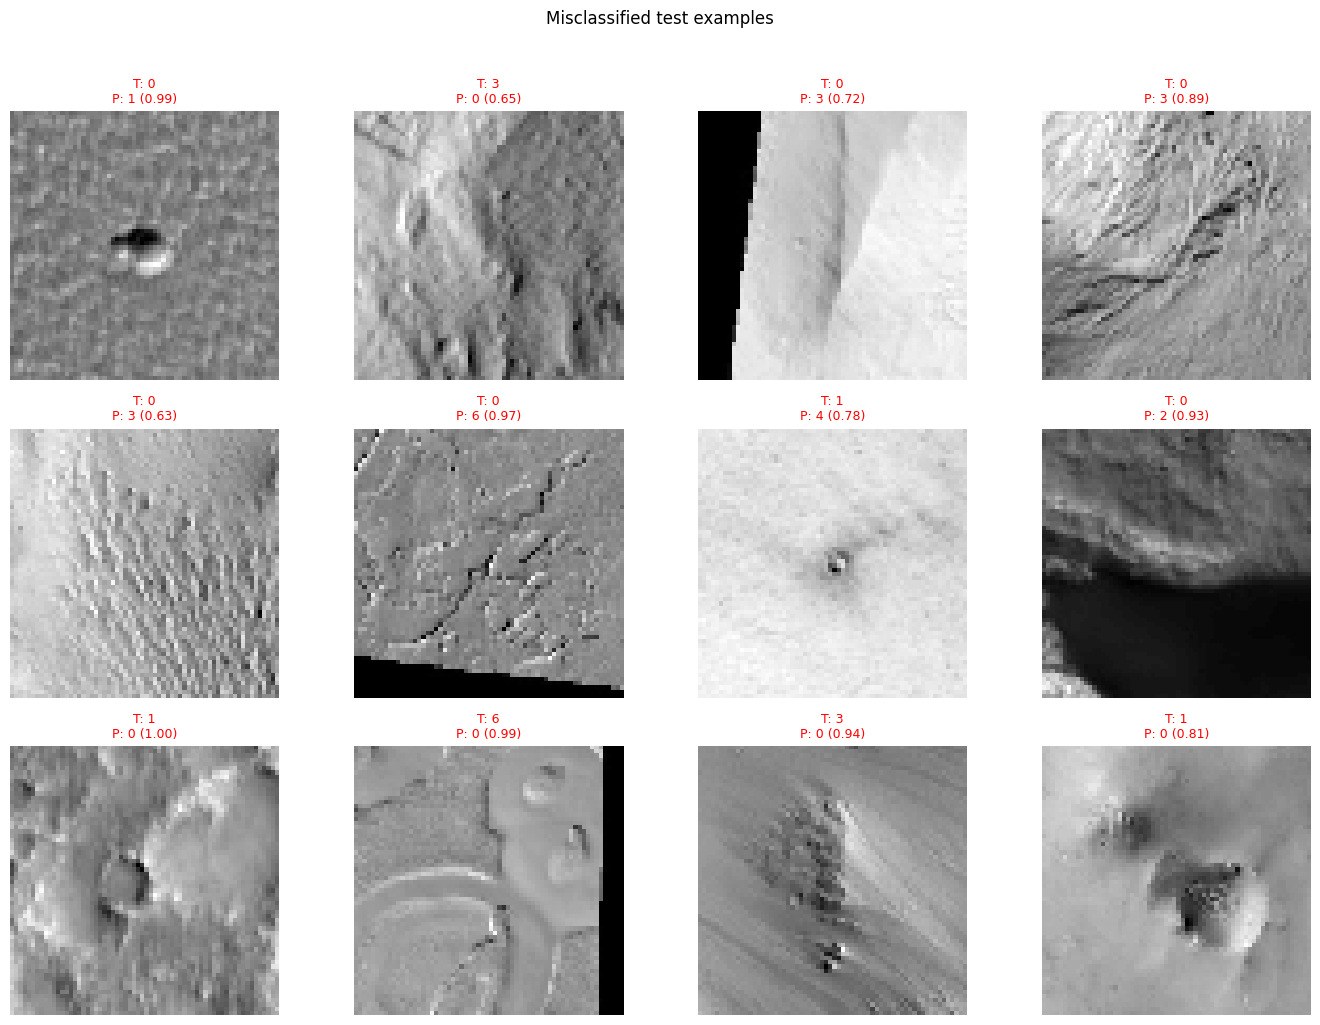

In [38]:
# Extra plot: misclassified examples gallery
wrong_df = test_df_reset[test_df_reset["true_label"] != test_df_reset["pred_label"]].copy()

if len(wrong_df) > 0:
    wrong_sample = wrong_df.sample(n=min(12, len(wrong_df)), random_state=SEED).reset_index(drop=True)

    plt.figure(figsize=(14, 10))
    for i, row in wrong_sample.iterrows():
        ax = plt.subplot(3, 4, i + 1)
        img = load_img(row["filepath"], color_mode=COLOR_MODE, target_size=IMG_SIZE)
        arr = img_to_array(img) / 255.0
        if arr.shape[-1] == 1:
            ax.imshow(arr.squeeze(), cmap="gray")
        else:
            ax.imshow(arr)
        ax.set_title(f"T: {row['true_label']}\nP: {row['pred_label']} ({row['pred_conf']:.2f})",
                     fontsize=9, color="red")
        ax.axis("off")
    plt.suptitle("Misclassified test examples", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples found.")

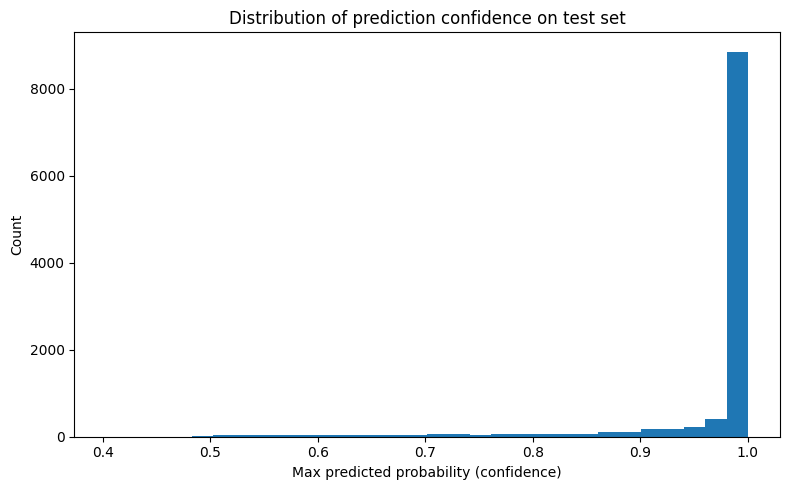

In [39]:
# Extra plot: prediction confidence distribution
pred_conf = y_prob.max(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(pred_conf, bins=30)
plt.xlabel("Max predicted probability (confidence)")
plt.ylabel("Count")
plt.title("Distribution of prediction confidence on test set")
plt.tight_layout()
plt.show()

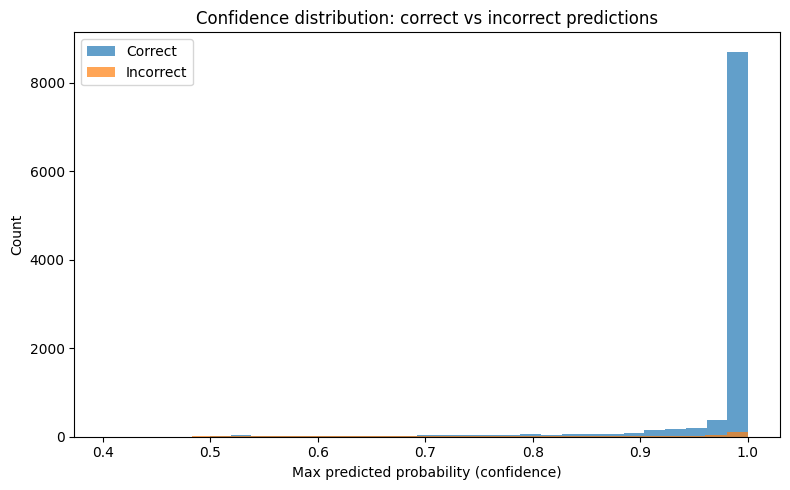

In [40]:
# Extra plot: confidence for correct vs incorrect predictions
is_correct = (y_true == y_pred)
correct_conf = y_prob.max(axis=1)[is_correct]
wrong_conf = y_prob.max(axis=1)[~is_correct]

plt.figure(figsize=(8, 5))
plt.hist(correct_conf, bins=30, alpha=0.7, label="Correct")
plt.hist(wrong_conf, bins=30, alpha=0.7, label="Incorrect")
plt.xlabel("Max predicted probability (confidence)")
plt.ylabel("Count")
plt.title("Confidence distribution: correct vs incorrect predictions")
plt.legend()
plt.tight_layout()
plt.show()